In [ ]:
from scipy.stats import binom
import matplotlib.pyplot as plt
import random
import numpy as np


Simulation over the Whole Protein Sequence

n=103, p=0.0343, target sites=21
P(0 hits) = 0.0276
P(≥1 hit) = 0.9724


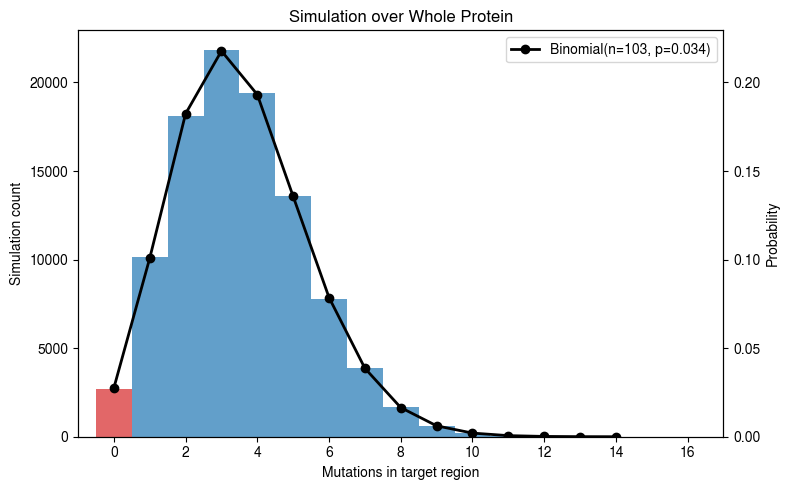

In [8]:
mutations = 103
target = list(range(472,489))+[469,494,501,505] # Residues within 5.5 angstroms of selectivity filter
trials = 100000
results = []
total_positions = 613 

# Simulation
for _ in range(trials):
    count = 0
    for _ in range(mutations):
        pos = random.randint(1, 613)
        if pos in (target):
            count += 1
    results.append(count)
    
p = len(target) / total_positions
print(f"n={mutations}, p={p:.4f}, target sites={len(target)}")

# Exact probability of 0 mutations in region
print(f"P(0 hits) = {binom.pmf(0, mutations, p):.4f}")
print(f"P(≥1 hit) = {1 - binom.pmf(0, mutations, p):.4f}")

# Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

# Simulated counts as bars
bins = np.arange(min(results), max(results) + 2) - 0.5
counts, edges = np.histogram(results, bins=bins)
bin_centers = edges[:-1] + 0.5

for i, (x, c) in enumerate(zip(bin_centers, counts)):
    ax1.bar(x, c, width=1.0, color="tab:red" if x == 0 else "tab:blue", alpha=0.7)

# Binomial PMF overlay on secondary axis
ax2 = ax1.twinx()
x_vals = np.arange(min(results), max(results) + 1)
ax2.plot(x_vals, binom.pmf(x_vals, mutations, p), 'o-', 
         color='black', linewidth=2, label=f'Binomial(n={mutations}, p={p:.3f})')

ax1.set_xlabel('Mutations in target region')
ax1.set_ylabel('Simulation count')
ax1.set_xlim(-1,17)
ax1.set_title("Simulation over Whole Protein")
ax2.set_ylabel('Probability')
ax2.set_ylim(0, ax1.get_ylim()[1] / trials)
ax2.legend()

plt.tight_layout()
plt.show()

Simulation Over the Pore Region

n=21, p=0.2727, target sites=21
P(0 hits) = 0.0012
P(≥1 hit) = 0.9988


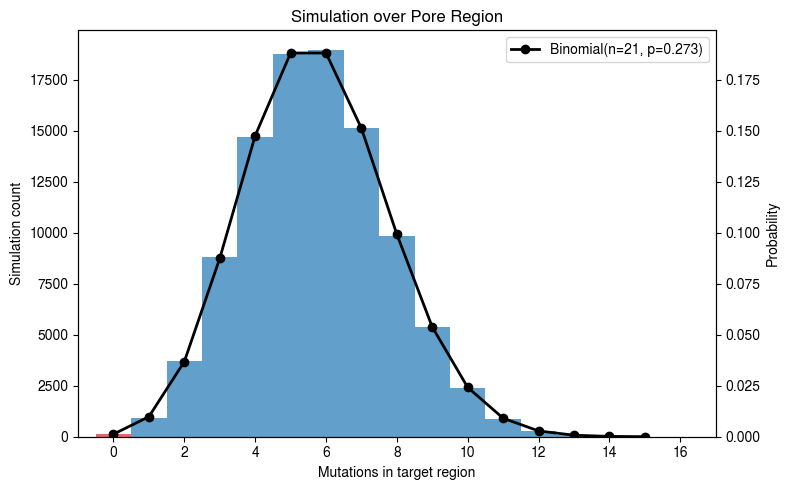

In [ ]:
mutations = 21
target = list(range(472,489))+[469,494,501,505] # Residues within 5.5 angstroms of selectivity filter
trials = 100000
results = []
total_positions = 525 - 449 + 1 

# Simulation
for _ in range(trials):
    count = 0
    for _ in range(mutations):
        pos = random.randint(449, 525)
        if pos in (target):
            count += 1
    results.append(count)
    
p = len(target) / total_positions
print(f"n={mutations}, p={p:.4f}, target sites={len(target)}")

# Exact probability of 0 mutations in region
print(f"P(0 hits) = {binom.pmf(0, mutations, p):.4f}")
print(f"P(≥1 hit) = {1 - binom.pmf(0, mutations, p):.4f}")

# Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

# Simulated counts as bars
bins = np.arange(min(results), max(results) + 2) - 0.5
counts, edges = np.histogram(results, bins=bins)
bin_centers = edges[:-1] + 0.5

for i, (x, c) in enumerate(zip(bin_centers, counts)):
    ax1.bar(x, c, width=1.0, color="tab:red" if x == 0 else "tab:blue", alpha=0.7)

# Binomial PMF overlay on secondary axis
ax2 = ax1.twinx()
x_vals = np.arange(min(results), max(results) + 1)
ax2.plot(x_vals, binom.pmf(x_vals, mutations, p), 'o-', 
         color='black', linewidth=2, label=f'Binomial(n={mutations}, p={p:.3f})')

ax1.set_xlabel('Mutations in target region')
ax1.set_ylabel('Simulation count')
ax1.set_xlim(-1,17)
ax1.set_title("Simulation over Pore Region")
ax2.set_ylabel('Probability')
ax2.set_ylim(0, ax1.get_ylim()[1] / trials)
ax2.legend()

plt.tight_layout()
plt.show()